<a href="https://colab.research.google.com/github/shubh-1009/MLE-LABS/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv('house_prices_practice.csv')

preview first 5 rows

In [17]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


preview last 5 rows

In [18]:
df.tail()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
295,296,1,3495,1,1792,1954,2,5,4978,250604
296,297,5,3438,3,1266,2003,0,1,9373,329906
297,298,6,1992,0,1148,1996,1,1,7907,184623
298,299,3,3722,1,1407,1998,1,1,8097,303345
299,300,9,1667,0,988,1958,2,1,14553,204982


check no of rows and columns

In [19]:
df.shape

(300, 10)

check column data types and non-null counts

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


summary of dataset

In [21]:
df.describe()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


check for missing values in eac column

In [22]:
print(df.isnull().sum())

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


check for duplicate rows

In [23]:
print(df.duplicated().sum())

0


Logistic Regression

In [24]:
df['Expensive'] = (df['SalePrice'] > df['SalePrice'].median()).astype(int)
df[['SalePrice','Expensive']].head()

,SalePrice,Expensive
0,177106,0
1,301044,1
2,360609,1
3,240556,0
4,193656,0


In [25]:
x=df['GrLivArea'].values
y=df['Expensive'].values

x_norm = (x-x.mean())/x.std()

def sigmoid(z):
  return 1 / (1+np.exp(-z))

In [26]:
m=len(y)
theta0,theta1=3.0,3.0
alpha=0.1
iterations=1000

for i in range(iterations):
  z=theta0+theta1*x_norm
  h=sigmoid(z)
  error=h-y
  theta0-=alpha*(1/m)*np.sum(error)
  theta1-=alpha*(1/m)*np.sum(error*x_norm)

print("Theta0:",theta0)
print("Theta1:",theta1)

Theta0: 0.005171710883329654
Theta1: 1.8732157877728564


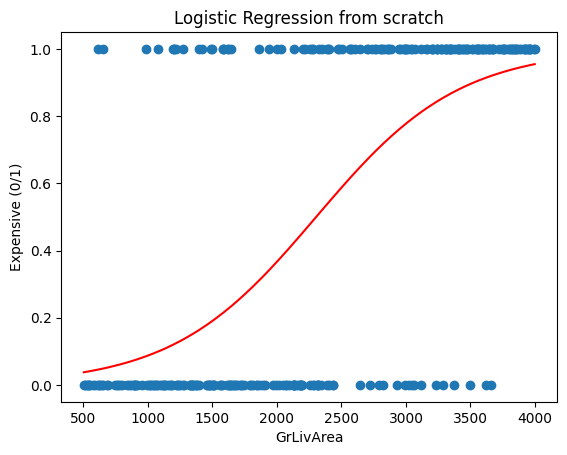

In [27]:
x_sorted=np.sort(x)
x_sorted_norm=(x_sorted-x.mean())/x.std()
y_curve=sigmoid(theta0+theta1*x_sorted_norm)

plt.scatter(x,y,alpha=1)
plt.plot(x_sorted,y_curve,color='red')
plt.xlabel('GrLivArea')
plt.ylabel('Expensive (0/1)')
plt.title("Logistic Regression from scratch")
plt.show()

using Scikit learn

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [29]:
x = df.drop(['Id','SalePrice','Expensive'],axis=1)
y = df['Expensive']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [30]:
log_model= LogisticRegression(max_iter=1000)
log_model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [31]:
y_pred = log_model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy: ",round(accuracy,4))

Accuracy:  0.95
